In [ ]:
import pandas as pd
# Phase 1 DATA UNDERSTANDING

df=pd.read_csv("fake_job_postings.csv")
print(df.shape,df.info())

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [7]:
print(df.describe())

             job_id  telecommuting  has_company_logo  has_questions  \
count  17880.000000   17880.000000      17880.000000   17880.000000   
mean    8940.500000       0.042897          0.795302       0.491723   
std     5161.655742       0.202631          0.403492       0.499945   
min        1.000000       0.000000          0.000000       0.000000   
25%     4470.750000       0.000000          1.000000       0.000000   
50%     8940.500000       0.000000          1.000000       0.000000   
75%    13410.250000       0.000000          1.000000       1.000000   
max    17880.000000       1.000000          1.000000       1.000000   

         fraudulent  
count  17880.000000  
mean       0.048434  
std        0.214688  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  


In [9]:
print(df.head())

   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         description  \
0  Foo

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
title                      0
fraudulent                 0
dtype: int64


# Missing Values Analysis
Top 5 columns with highest missing values:
- salary_range
- department
- required_education
- benifits
- required_expereince

In [12]:
print(df["fraudulent"].value_counts())

fraudulent
0    17014
1      866
Name: count, dtype: int64


# Target Variable Analysis
866 / (17014 + 866) = 0.048
- The dataset is imbalanced.
- Majority are real jobs (95%).
- Only 4.8% jobs are fake.

This means fake jobs are rare compared to real jobs.

In [ ]:
# Phase 2 DATA CLEANING
df.drop("job_id",axis=1,inplace=True) #drops usless column
df.drop(["salary_range", "department"], axis=1, inplace=True) #drop column with too many null values
cols_to_fill = [
    "required_education",
    "benefits",
    "required_experience",
    "function",
    "industry",
    "employment_type",
    "company_profile",
    "requirements"
]                               
df[cols_to_fill] = df[cols_to_fill].fillna("Unknown") #fill the null value
df.isnull().sum() #checking for null values

title                    0
location               346
company_profile          0
description              1
requirements             0
benefits                 0
telecommuting            0
has_company_logo         0
has_questions            0
employment_type          0
required_experience      0
required_education       0
industry                 0
function                 0
fraudulent               0
dtype: int64

In [18]:
df["location"] = df["location"].fillna("Unknown")
df["description"] = df["description"].fillna("Unknown")
df.isnull().sum() #checking for null values

title                  0
location               0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

In [ ]:
# removing duplicate values
df.drop_duplicates(inplace=True) 
df.duplicated().sum()

0

In [ ]:
# Text Preprocessing / Text Cleaning
cols_to_clean = ["description", "requirements", "company_profile"]
for col in cols_to_clean:
    df[col] = df[col].str.lower()          
    df[col] = df[col].str.strip()          
    df[col] = df[col].str.replace(r"\s+", " ", regex=True)  

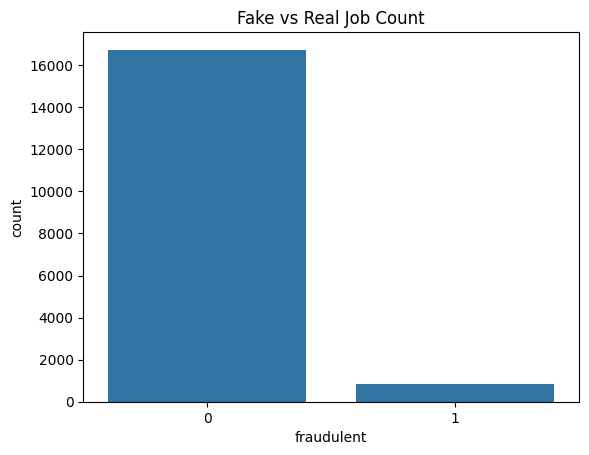

In [25]:
# Phase 3 ANALYSIS
import seaborn as sns
import matplotlib.pyplot as plt

# Fake vs Real Jobs
sns.countplot(x="fraudulent", data=df)
plt.title("Fake vs Real Job Count")
plt.show()

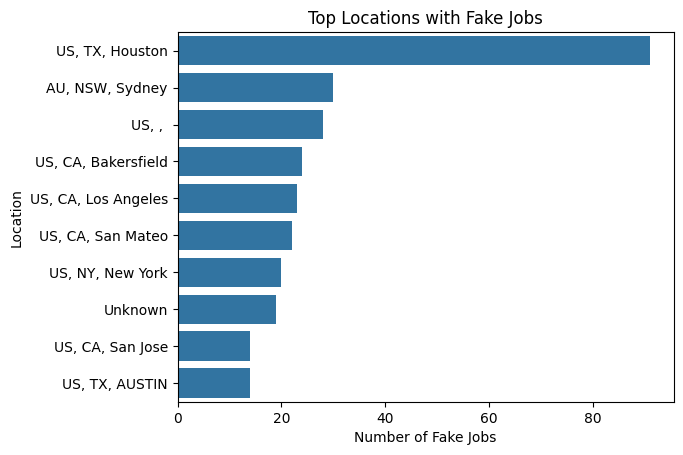

In [ ]:
# Top locations with fake job
fake_jobs = df[df["fraudulent"] == 1]
top_locations = fake_jobs["location"].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top Locations with Fake Jobs")
plt.xlabel("Number of Fake Jobs")
plt.ylabel("Location")
plt.show()

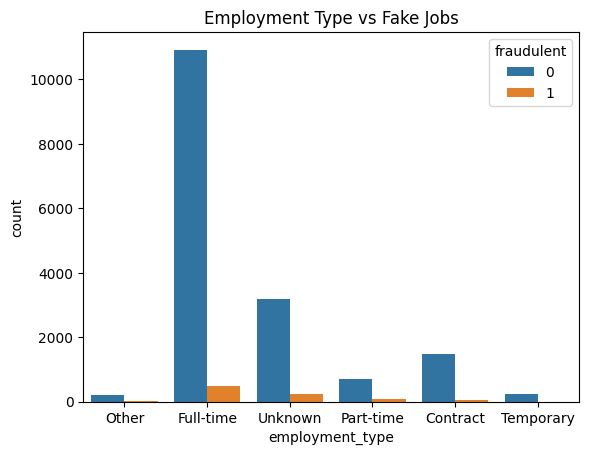

In [ ]:
# To check which job is more fake
sns.countplot(x="employment_type", hue="fraudulent", data=df)
plt.title("Employment Type vs Fake Jobs")
plt.show()

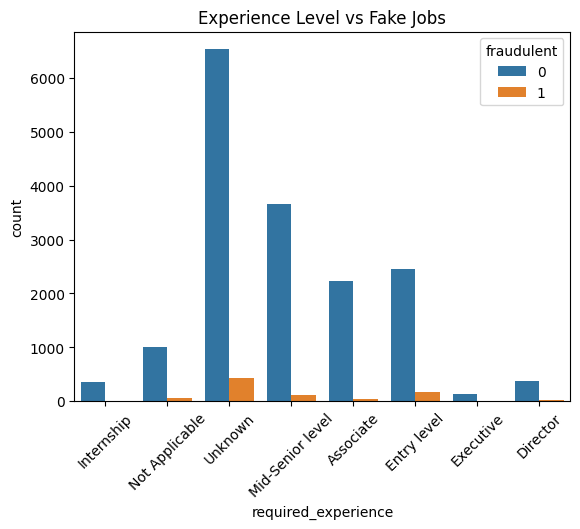

In [ ]:
#  Experience level vs fake
sns.countplot(x="required_experience", hue="fraudulent", data=df)
plt.title("Experience Level vs Fake Jobs")
plt.xticks(rotation=45)
plt.show()

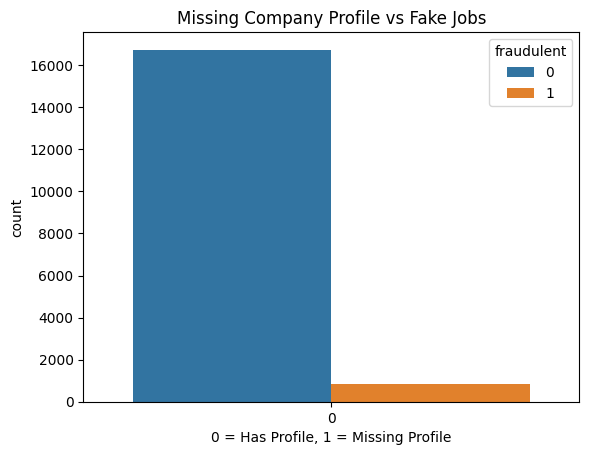

In [31]:
# To find fake we see missing company profile -> fake
df["company_profile_missing"] = df["company_profile"].apply(
    lambda x: 1 if x == "Unknown" else 0
)

sns.countplot(x="company_profile_missing", hue="fraudulent", data=df)
plt.title("Missing Company Profile vs Fake Jobs")
plt.xlabel("0 = Has Profile, 1 = Missing Profile")
plt.show()

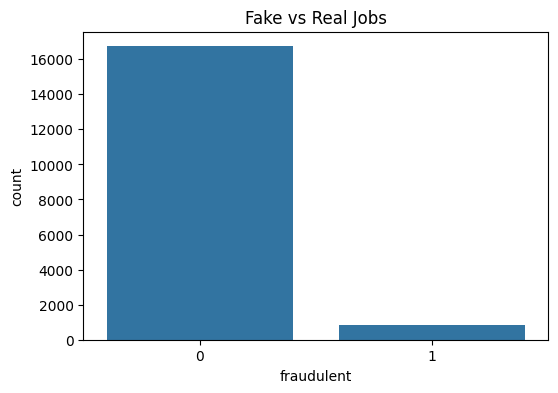

In [ ]:
# Phase 4 VISUALIZATION

plt.figure(figsize=(6,4))
sns.countplot(x="fraudulent", data=df)
plt.title("Fake vs Real Jobs")
plt.savefig("images/fake_vs_real.png")
plt.show()

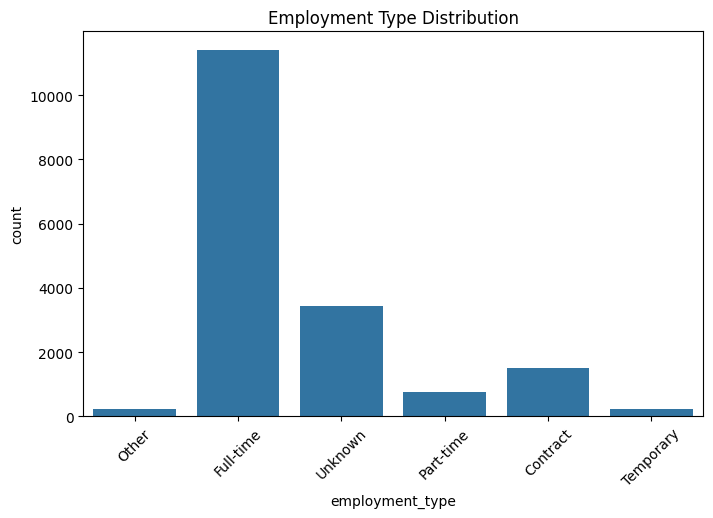

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x="employment_type", data=df)
plt.title("Employment Type Distribution")
plt.xticks(rotation=45)
plt.savefig("images/employment_type.png")
plt.show()

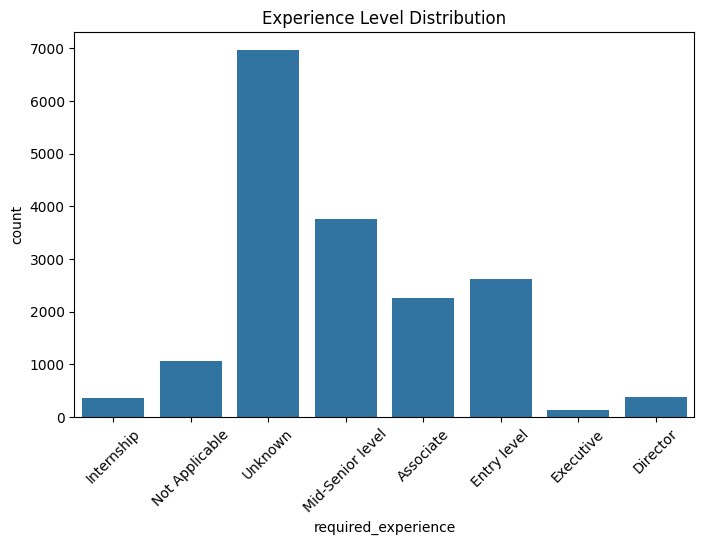

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x="required_experience", data=df)
plt.title("Experience Level Distribution")
plt.xticks(rotation=45)
plt.savefig("images/experience_level.png")
plt.show()

# Histogram salary range 
Salary analysis not performed due to high missing values

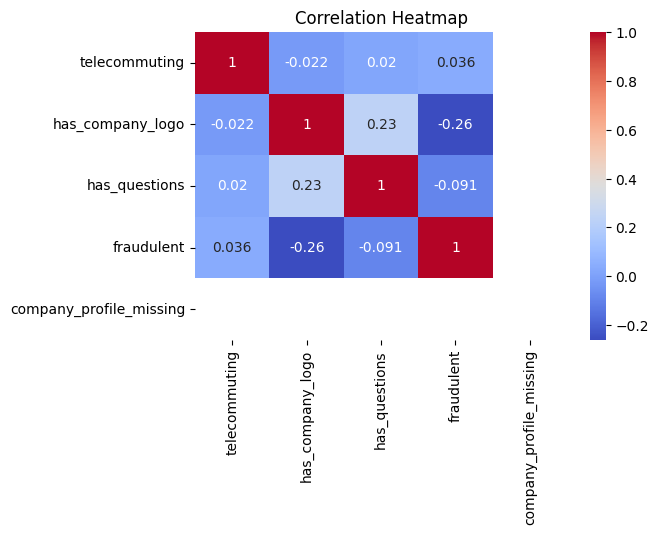

In [35]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png")
plt.show()

# Visualization
- Created plots to understand distribution and patterns
- Saved plots for reporting and GitHub display

# Phase 5 INSIGHT
-The count of fake jobs as compare to real are less that is 2/3 out of 10 jobs are fake rest are real
-The likelihood of fake job based on location is found more in the US,TX,Houston which very large number of fake jbs been found there followed up by AU,NSW,Sydney
-The fake jobs are found more in full-time employment type with not specified positioning as required experience
-The more you find missing company profile the more likely it is fake job